<a href="https://colab.research.google.com/github/farazaghajani-eng/repowering_flexibility_optimization/blob/main/Game_dream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Install the solver and pyomo
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

import pyomo.environ as pyo

# -----------------------------
# SETS & PROBABILITY
# -----------------------------
T = range(12)
G = ["gen1", "gen2"]
S = ["PSH1"]
Omega = ["low", "medium", "high"]
prob = {"low": 0.3, "medium": 0.5, "high": 0.2}

# -----------------------------
# PARAMETERS
# -----------------------------
Pmax = {"gen1": 250, "gen2": 300}
Pmin = {"gen1": 100, "gen2": 100}
RampUp = {"gen1": 60, "gen2": 70}
RampDown = {"gen1": 60, "gen2": 70}
Cost = {"gen1": 20, "gen2": 25}
StartupCost = {"gen1": 100, "gen2": 120}
Emission_Rate = {"gen1": 0.5, "gen2": 0.3}
Carbon_Tax = 50
VOLL = 5000
Repower_CAPEX = 500000
Repower_Capacity_Boost = 1500
Repower_Efficiency_Gain = 5

Pmax_s = {"PSH1": 200}
Emax = {"PSH1": 500}
Eff_c = {"PSH1": 0.9}
Eff_d = {"PSH1": 0.9}

demand = {
    (w, t): (1000 + 50 * t if w == "low" else 1500 + 50 * t if w == "medium" else 2000 + 50 * t)
    for w in Omega for t in T
}

# Additional parameters for flexibility enhancement from repowering
Repower_Pmin_Reduction = 50 # MW reduction in Pmin for gen1 if repowered
Repower_RampUp_Boost = 20  # MW/h increase in RampUp for gen1 if repowered
Repower_RampDown_Boost = 20 # MW/h increase in RampDown for gen1 if repowered

# -----------------------------
# MODEL
# -----------------------------
m = pyo.ConcreteModel()
m.T, m.G, m.S, m.Omega = pyo.Set(initialize=T), pyo.Set(initialize=G), pyo.Set(initialize=S), pyo.Set(initialize=Omega)

# VARIABLES
m.repower_invest = pyo.Var(within=pyo.Binary)
m.u = pyo.Var(m.G, m.T, within=pyo.Binary)
m.su = pyo.Var(m.G, m.T, within=pyo.Binary)
m.p = pyo.Var(m.G, m.T, m.Omega, within=pyo.NonNegativeReals)
m.charge = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.discharge = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.soc = pyo.Var(m.S, m.T, m.Omega, within=pyo.NonNegativeReals)
m.lshed = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)

# LINEARIZATION VARIABLES
# Linearize invest * p[g,t,w] (Only for gen1)
m.repower_prod_p = pyo.Var(m.T, m.Omega, within=pyo.NonNegativeReals)
# Linearize invest * u[g,t] (Only for gen1)
m.invest_u_link = pyo.Var(m.T, within=pyo.Binary)

# OBJECTIVE
def obj_rule(m):
    investment_cost = m.repower_invest * Repower_CAPEX
    startup_costs = sum(StartupCost[g] * m.su[g, t] for g in m.G for t in m.T)
    expected_op_cost = 0
    for w in m.Omega:
        # FIXED: Only use repower_prod_p for gen1
        scenario_cost = sum(
            (Cost[g] + Emission_Rate[g] * Carbon_Tax) * m.p[g, t, w] for g in m.G for t in m.T
        ) - sum(
            Repower_Efficiency_Gain * m.repower_prod_p[t, w] for t in m.T
        ) + sum(VOLL * m.lshed[t, w] for t in m.T)
        expected_op_cost += prob[w] * scenario_cost
    return investment_cost + startup_costs + expected_op_cost
m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# =============================================================================
# ALL CONSTRAINTS (consolidated to avoid re-definition warnings)
# =============================================================================

# Original constraints
def gen_max_rule(m, g, t, w):
    if g == "gen1":
        return m.p[g, t, w] <= Pmax[g] * m.u[g, t] + Repower_Capacity_Boost * m.invest_u_link[t]
    return m.p[g, t, w] <= Pmax[g] * m.u[g, t]
m.gen_max = pyo.Constraint(m.G, m.T, m.Omega, rule=gen_max_rule)

# Linearization constraints for invest * u[gen1, t]
def link_invest_u_1(m, t):
    return m.invest_u_link[t] <= m.repower_invest
m.link_u1 = pyo.Constraint(m.T, rule=link_invest_u_1)

def link_invest_u_2(m, t):
    return m.invest_u_link[t] <= m.u['gen1', t]
m.link_u2 = pyo.Constraint(m.T, rule=link_invest_u_2)

def link_invest_u_3(m, t):
    return m.invest_u_link[t] >= m.repower_invest + m.u['gen1', t] - 1
m.link_u3 = pyo.Constraint(m.T, rule=link_invest_u_3)

# Linearization for invest * p[gen1, t, w]
def lin1_rule(m, t, w):
    return m.repower_prod_p[t, w] <= m.p['gen1', t, w]
m.lin1 = pyo.Constraint(m.T, m.Omega, rule=lin1_rule)

def lin2_rule(m, t, w):
    M = Pmax['gen1'] + Repower_Capacity_Boost
    return m.repower_prod_p[t, w] <= M * m.repower_invest
m.lin2 = pyo.Constraint(m.T, m.Omega, rule=lin2_rule)

def lin3_rule(m, t, w):
    M = Pmax['gen1'] + Repower_Capacity_Boost
    return m.repower_prod_p[t, w] >= m.p['gen1', t, w] - M * (1 - m.repower_invest)
m.lin3 = pyo.Constraint(m.T, m.Omega, rule=lin3_rule)

# Balance, Startup, SOC (original)
def balance_rule(m, t, w):
    return (sum(m.p[g, t, w] for g in m.G) + sum(m.discharge[s, t, w] - m.charge[s, t, w] for s in m.S) + m.lshed[t, w] >= demand[(w, t)])
m.balance = pyo.Constraint(m.T, m.Omega, rule=balance_rule)

def startup_rule(m, g, t):
    if t == 0: return m.su[g, t] >= m.u[g, t]
    return m.su[g, t] >= m.u[g, t] - m.u[g, t-1]
m.startup = pyo.Constraint(m.G, m.T, rule=startup_rule)

def soc_rule(m, s, t, w):
    if t == 0: return m.soc[s, t, w] == 100
    return m.soc[s, t, w] == m.soc[s, t-1, w] + Eff_c[s]*m.charge[s, t, w] - m.discharge[s, t, w]/Eff_d[s]
m.soc_dyn = pyo.Constraint(m.S, m.T, m.Omega, rule=soc_rule)

def soc_limit(m, s, t, w):
    return m.soc[s, t, w] <= Emax[s]
m.soc_lim = pyo.Constraint(m.S, m.T, m.Omega, rule=soc_limit)

# =============================================================================
# NEW: Standard UC constraints (added for completeness)
# =============================================================================
def gen_min_rule(m, g, t, w):
    """Minimum stable generation when a unit is committed (standard UC constraint).
    Includes Pmin reduction for repowered gen1."""
    if g == "gen1":
        # Pmin reduction if repowered, linked via invest_u_link for linearity
        return m.p[g, t, w] >= Pmin[g] * m.u[g, t] - Repower_Pmin_Reduction * m.invest_u_link[t]
    else:
        return m.p[g, t, w] >= Pmin[g] * m.u[g, t]
m.gen_min = pyo.Constraint(m.G, m.T, m.Omega, rule=gen_min_rule)

# 9. RAMP CONSTRAINTS (modified for repowering flexibility)
def ramp_up_rule(m, g, t, w):
    if t == 0:
        return pyo.Constraint.Skip
    if g == "gen1":
        # RampUp increase if repowered
        return m.p[g, t, w] - m.p[g, t - 1, w] <= RampUp[g] + Repower_RampUp_Boost * m.repower_invest
    else:
        return m.p[g, t, w] - m.p[g, t - 1, w] <= RampUp[g]

def ramp_down_rule(m, g, t, w):
    if t == 0:
        return pyo.Constraint.Skip
    if g == "gen1":
        # RampDown increase if repowered
        return m.p[g, t - 1, w] - m.p[g, t, w] <= RampDown[g] + Repower_RampDown_Boost * m.repower_invest
    else:
        return m.p[g, t - 1, w] - m.p[g, t, w] <= RampDown[g]

m.ramp_up   = pyo.Constraint(m.G, m.T, m.Omega, rule=ramp_up_rule)
m.ramp_down = pyo.Constraint(m.G, m.T, m.Omega, rule=ramp_down_rule)

# SOLVE
solver = pyo.SolverFactory("glpk")
results = solver.solve(m)

print(f"Repowering Investment Decided: {'YES' if pyo.value(m.repower_invest) > 0.5 else 'NO'}")
print(f"Total Expected System Cost: ${pyo.value(m.obj):,.2f}")

Repowering Investment Decided: YES
Total Expected System Cost: $3,956,460.00


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting data from the solved Pyomo model
data = []
for w in m.Omega:
    for t in m.T:
        total_generation = sum(pyo.value(m.p[g, t, w]) for g in m.G)
        load_shed = pyo.value(m.lshed[t, w])
        actual_demand = demand[(w, t)]
        data.append({
            'Scenario': w,
            'Time': t,
            'Total Generation': total_generation,
            'Demand': actual_demand,
            'Load Shedding': load_shed
        })

df_results = pd.DataFrame(data)

# Display the first few rows of the results dataframe
print("Extracted Model Results:")
display(df_results.head())

Extracted Model Results:


,Scenario,Time,Total Generation,Demand,Load Shedding
0,low,0,810.0,1000,0.0
1,low,1,960.0,1050,0.0
2,low,2,1100.0,1100,0.0
3,low,3,1150.0,1150,0.0
4,low,4,1200.0,1200,0.0


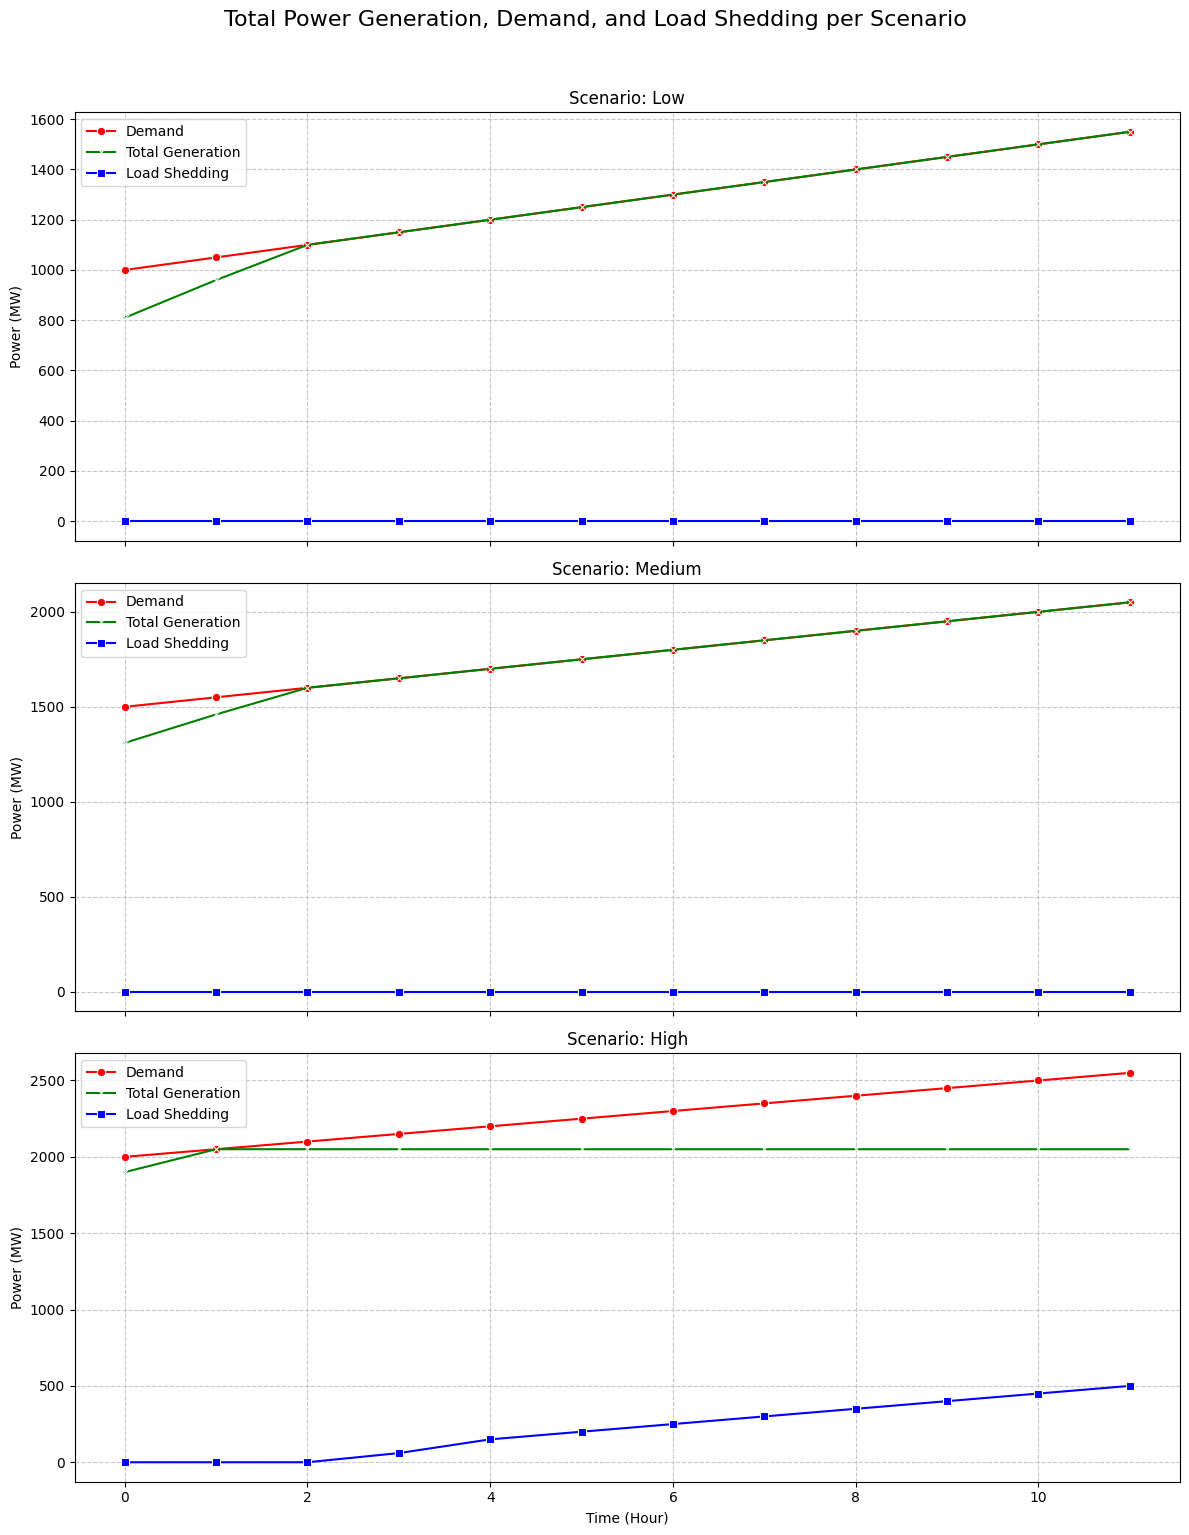

In [23]:
fig, axes = plt.subplots(nrows=len(m.Omega), ncols=1, figsize=(12, 5 * len(m.Omega)), sharex=True)
fig.suptitle('Total Power Generation, Demand, and Load Shedding per Scenario', y=1.02, fontsize=16)

for i, w in enumerate(m.Omega):
    ax = axes[i]
    scenario_df = df_results[df_results['Scenario'] == w]

    sns.lineplot(x='Time', y='Demand', data=scenario_df, ax=ax, label='Demand', marker='o', color='red')
    sns.lineplot(x='Time', y='Total Generation', data=scenario_df, ax=ax, label='Total Generation', marker='x', color='green')
    sns.lineplot(x='Time', y='Load Shedding', data=scenario_df, ax=ax, label='Load Shedding', marker='s', color='blue')

    ax.set_title(f'Scenario: {w.capitalize()}')
    ax.set_ylabel('Power (MW)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

ax.set_xlabel('Time (Hour)')
plt.tight_layout()
plt.show()


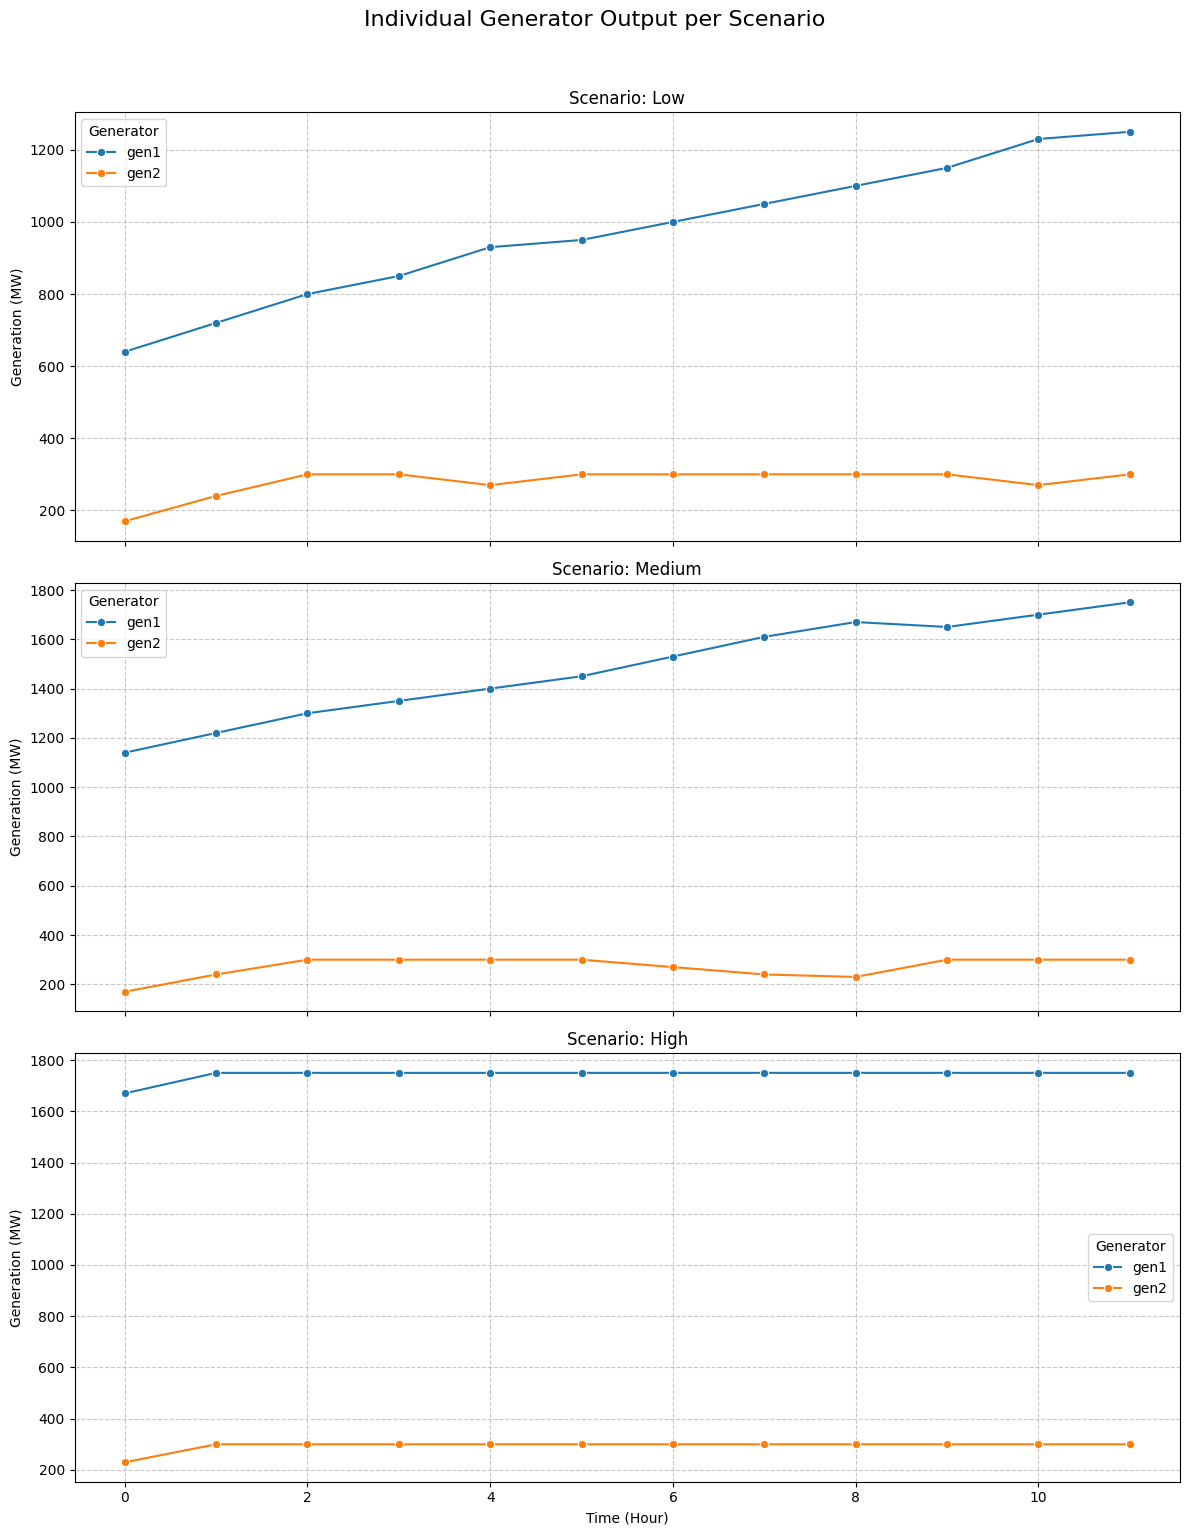

In [24]:
# Extracting individual generator output data
gen_data = []
for w in m.Omega:
    for t in m.T:
        for g in m.G:
            gen_data.append({
                'Scenario': w,
                'Time': t,
                'Generator': g,
                'Generation': pyo.value(m.p[g, t, w])
            })

df_gen_output = pd.DataFrame(gen_data)

fig, axes = plt.subplots(nrows=len(m.Omega), ncols=1, figsize=(12, 5 * len(m.Omega)), sharex=True)
fig.suptitle('Individual Generator Output per Scenario', y=1.02, fontsize=16)

for i, w in enumerate(m.Omega):
    ax = axes[i]
    scenario_gen_df = df_gen_output[df_gen_output['Scenario'] == w]

    sns.lineplot(x='Time', y='Generation', hue='Generator', data=scenario_gen_df, ax=ax, marker='o')

    ax.set_title(f'Scenario: {w.capitalize()}')
    ax.set_ylabel('Generation (MW)')
    ax.legend(title='Generator')
    ax.grid(True, linestyle='--', alpha=0.7)

ax.set_xlabel('Time (Hour)')
plt.tight_layout()
plt.show()


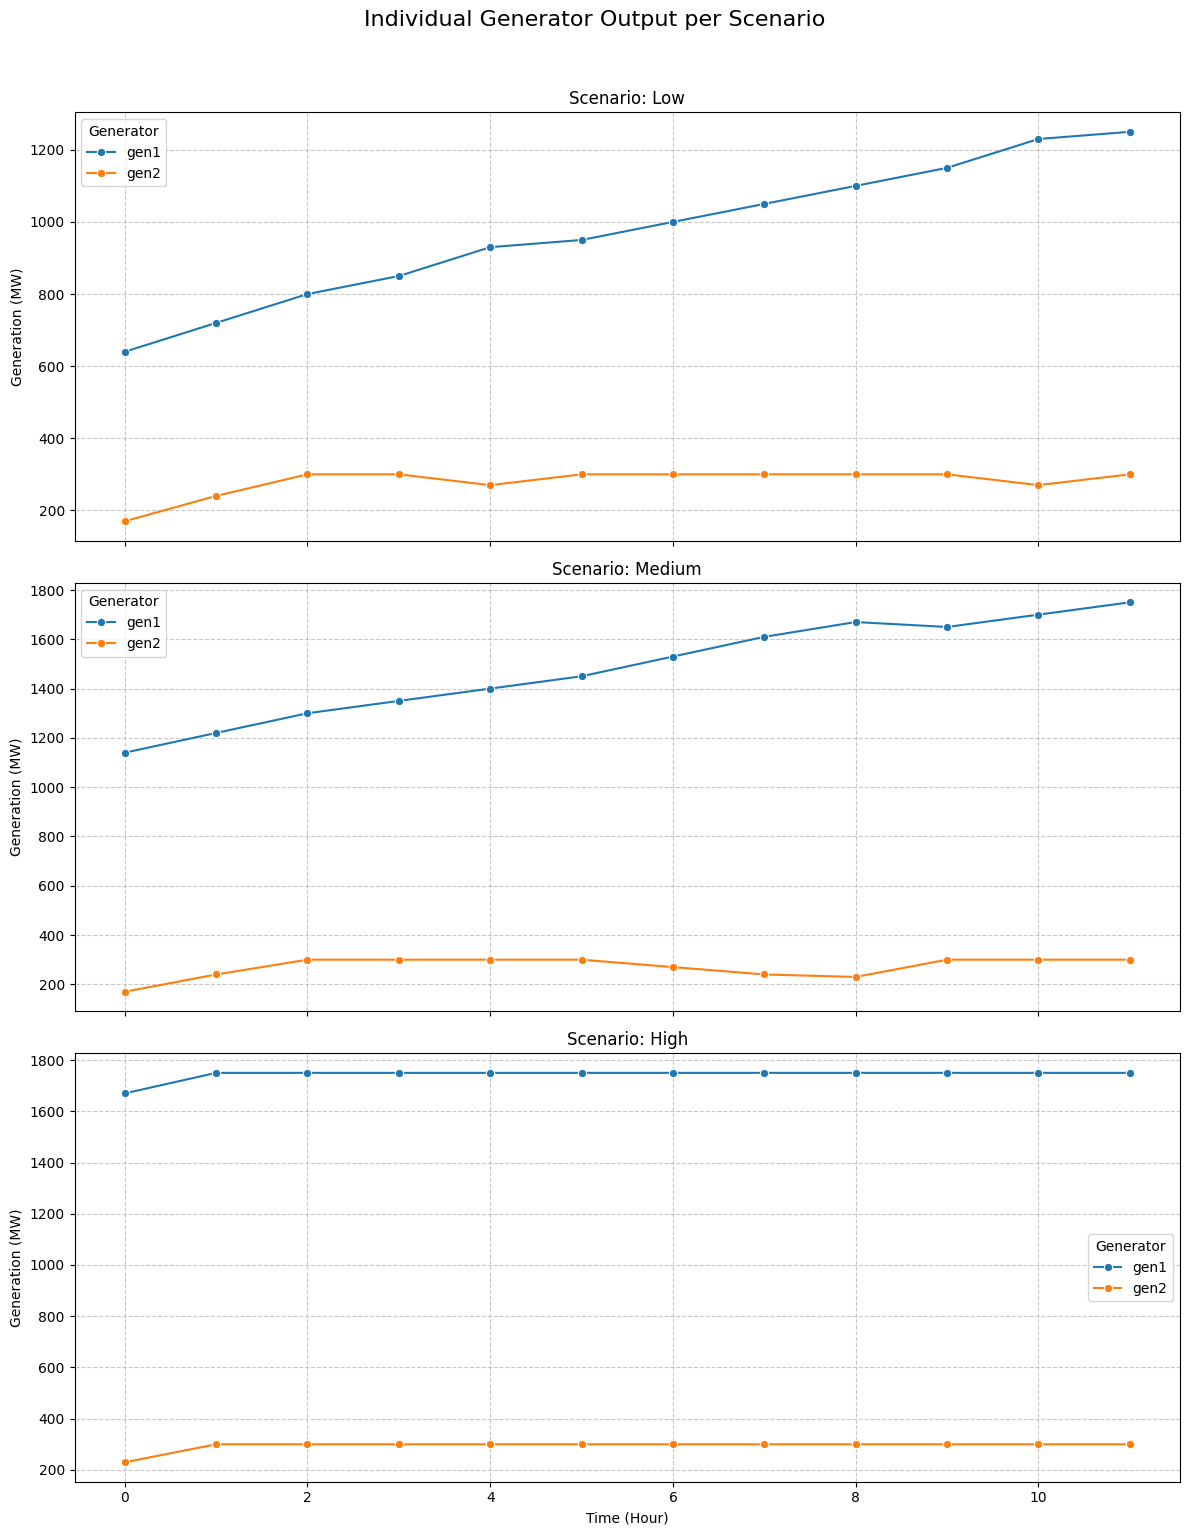

In [25]:
# Extracting individual generator output data
gen_data = []
for w in m.Omega:
    for t in m.T:
        for g in m.G:
            gen_data.append({
                'Scenario': w,
                'Time': t,
                'Generator': g,
                'Generation': pyo.value(m.p[g, t, w])
            })

df_gen_output = pd.DataFrame(gen_data)

fig, axes = plt.subplots(nrows=len(m.Omega), ncols=1, figsize=(12, 5 * len(m.Omega)), sharex=True)
fig.suptitle('Individual Generator Output per Scenario', y=1.02, fontsize=16)

for i, w in enumerate(m.Omega):
    ax = axes[i]
    scenario_gen_df = df_gen_output[df_gen_output['Scenario'] == w]

    sns.lineplot(x='Time', y='Generation', hue='Generator', data=scenario_gen_df, ax=ax, marker='o')

    ax.set_title(f'Scenario: {w.capitalize()}')
    ax.set_ylabel('Generation (MW)')
    ax.legend(title='Generator')
    ax.grid(True, linestyle='--', alpha=0.7)

ax.set_xlabel('Time (Hour)')
plt.tight_layout()
plt.show()
